# 📈 Nifty 50 Stock Market Predictor — Improved
This notebook improves on the baseline Random Forest model by:
1. Adding **more features** (RSI, MACD, Bollinger Bands, volatility)
2. Adding **multiple models** (RandomForest, GradientBoosting, XGBoost, LightGBM, VotingEnsemble)
3. **Threshold-tuned predictions** for better precision
4. A full **backtesting comparison** across all models

In [50]:
# !pip install yfinance xgboost lightgbm
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import precision_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('All libraries loaded ✓')

All libraries loaded ✓


## 1. Download Data

In [51]:
ticker = yf.Ticker('^NSEI')
df = ticker.history(period='max')

# Clean up
df.drop(columns=['Dividends', 'Stock Splits'], errors='ignore', inplace=True)
  # remove timezone for cleaner display

print(f'Data shape: {df.shape}')

df.tail(3)

Data shape: (4563, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2026-04-23 00:00:00+05:30,24202.349609,24310.199219,24134.800781,24173.050781,467500
2026-04-24 00:00:00+05:30,24100.550781,24206.000000,23813.650391,23897.949219,438400
2026-04-27 00:00:00+05:30,23945.449219,24129.550781,23936.199219,24093.900391,0


## 2. Feature Engineering
We add technical indicators on top of the rolling ratio/trend features from the baseline.

In [52]:
def add_features(data):
    df = data.copy()

    # ── Multi-day Returns (%) ───────────────────────────────────
    df['Return_1d'] = df['Close'].pct_change(1) * 100
    df['Return_3d'] = df['Close'].pct_change(3) * 100
    df['Return_5d'] = df['Close'].pct_change(5) * 100
    df['Return_10d'] = df['Close'].pct_change(10) * 100

    # ── Future Multi-day Returns (for target) ────────────────────
    df['Return_3d_Future'] = df['Close'].shift(-3).pct_change(3) * 100
    df['Return_5d_Future'] = df['Close'].shift(-5).pct_change(5) * 100

    # ── Targets ─────────────────────────────────────────────────
    # Simple direction (1 = UP, 0 = DOWN/FLAT)
    df['Target_Direction'] = (df['Return_3d_Future'] > 0).astype(int)
    
    # Noise filtering: only label strong moves (>0.3% move, ignore micro-moves)
    NOISE_THRESHOLD = 0.3
    df['Target_Strong'] = np.where(
        np.abs(df['Return_3d_Future']) > NOISE_THRESHOLD,
        df['Target_Direction'],
        -1  # -1 = NO TRADE signal (ignore small noise)
    )
    
    # Magnitude target (actual 3-day return %)
    df['Target_Magnitude'] = df['Return_3d_Future']

    # ── Baseline rolling ratio + trend ──────────────────────────
    horizons = [2, 5, 60, 250, 1000]
    for h in horizons:
        roll = df.rolling(h).mean()
        df[f'Close_{h}_ratio'] = df['Close'] / roll['Close']
        df[f'Trend_{h}']       = df.shift(1).rolling(h).sum()['Target_Direction']

    # ── Moving Averages ────────────────────────────────────────
    df['MA_5']   = df['Close'].rolling(5).mean()
    df['MA_20']  = df['Close'].rolling(20).mean()
    df['MA_50']  = df['Close'].rolling(50).mean()
    df['MA_200'] = df['Close'].rolling(200).mean()
    
    # Trend strength: MA ratios
    df['Trend_5_20']   = df['MA_5'] / df['MA_20'].replace(0, np.nan)
    df['Trend_20_50']  = df['MA_20'] / df['MA_50'].replace(0, np.nan)
    df['Trend_50_200'] = df['MA_50'] / df['MA_200'].replace(0, np.nan)
    
    # Price position relative to MAs
    df['Price_vs_MA20'] = df['Close'] / df['MA_20'].replace(0, np.nan)
    df['Price_vs_MA50'] = df['Close'] / df['MA_50'].replace(0, np.nan)

    # ── Volatility Regimes ──────────────────────────────────────
    df['Volatility_10'] = df['Close'].pct_change().rolling(10).std() * 100
    df['Volatility_30'] = df['Close'].pct_change().rolling(30).std() * 100
    df['Volatility_Ratio'] = df['Volatility_10'] / df['Volatility_30'].replace(0, np.nan)
    
    # High/Low volatility regime (binary)
    vol_median = df['Volatility_30'].rolling(60).median()
    df['High_Vol_Regime'] = (df['Volatility_30'] > vol_median).astype(int)

    # ── Volume Analysis ────────────────────────────────────────
    df['Volume_MA_20'] = df['Volume'].rolling(20).mean()
    df['Volume_Spike'] = df['Volume'] / df['Volume_MA_20'].replace(0, np.nan)
    df['Volume_Trend'] = df['Volume'].pct_change(5)

    # ── RSI (14-day) ───────────────────────────────────────────
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    df['RSI_14'] = 100 - (100 / (1 + rs))
    df['RSI_Extreme'] = ((df['RSI_14'] < 30) | (df['RSI_14'] > 70)).astype(int)

    # ── MACD ────────────────────────────────────────────────────
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD']        = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']
    df['MACD_Positive'] = (df['MACD_Hist'] > 0).astype(int)

    # ── Bollinger Bands ────────────────────────────────────────
    sma20  = df['Close'].rolling(20).mean()
    std20  = df['Close'].rolling(20).std()
    df['BB_Upper'] = sma20 + 2 * std20
    df['BB_Lower'] = sma20 - 2 * std20
    df['BB_Width'] = (2 * std20) / sma20.replace(0, np.nan)
    df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower']).replace(0, np.nan)

    # ── OHLC Ratios ───────────────────────────────────────────
    df['High_Low_Ratio'] = df['High'] / df['Low'].replace(0, np.nan)
    df['Open_Close']    = df['Open'] / df['Close'].replace(0, np.nan)
    df['Range'] = (df['High'] - df['Low']) / df['Close']

    # ── Rate of Change (momentum) ──────────────────────────────
    df['ROC_5']  = df['Close'].pct_change(5) * 100
    df['ROC_20'] = df['Close'].pct_change(20) * 100

    # Replace infinities with NaN and drop rows with missing values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

df = add_features(df)
print(f'Shape after feature engineering: {df.shape}')
df.tail(3)

Shape after feature engineering: (3219, 55)


,Open,High,Low,Close,Volume,Return_1d,Return_3d,Return_5d,Return_10d,Return_3d_Future,...,MACD_Positive,BB_Upper,BB_Lower,BB_Width,BB_Position,High_Low_Ratio,Open_Close,Range,ROC_5,ROC_20
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-16 00:00:00+05:30,24385.199219,24400.949219,24102.800781,24196.750000,508000,-0.142587,0.607679,0.830927,8.353035,1.569837,...,1,24485.934552,22148.570722,0.050121,0.876277,1.012370,1.007788,0.012322,0.830927,4.516634
2026-04-17 00:00:00+05:30,24165.900391,24371.900391,24096.050781,24353.550781,498600,0.648024,2.142800,2.433013,7.381811,0.100802,...,1,24621.766884,22107.213389,0.053811,0.893335,1.011448,0.992295,0.011327,2.433013,4.035875
2026-04-20 00:00:00+05:30,24391.500000,24480.650391,24241.250000,24364.849609,415900,0.046395,0.551142,1.306620,7.272235,-0.787195,...,1,24735.994490,22071.355705,0.056928,0.860715,1.009876,1.001094,0.009826,1.306620,3.323414


In [53]:
BASELINE_FEATURES = [
    'Close','Volume','Open','High','Low',
    'Close_2_ratio','Close_5_ratio','Close_60_ratio','Close_250_ratio','Close_1000_ratio',
    'Trend_2','Trend_5','Trend_60','Trend_250','Trend_1000'
]

MA_FEATURES = [
    'MA_5','MA_20','MA_50','MA_200',
    'Trend_5_20','Trend_20_50','Trend_50_200',
    'Price_vs_MA20','Price_vs_MA50'
]

VOLATILITY_FEATURES = [
    'Volatility_10','Volatility_30','Volatility_Ratio','High_Vol_Regime'
]

VOLUME_FEATURES = [
    'Volume_MA_20','Volume_Spike','Volume_Trend'
]

MOMENTUM_FEATURES = [
    'RSI_14','RSI_Extreme',
    'MACD','MACD_Signal','MACD_Hist','MACD_Positive',
    'ROC_5','ROC_20'
]

BB_FEATURES = [
    'BB_Upper','BB_Lower','BB_Width','BB_Position'
]

OHLC_FEATURES = [
    'High_Low_Ratio','Open_Close','Range'
]

ALL_FEATURES = BASELINE_FEATURES + MA_FEATURES + VOLATILITY_FEATURES + VOLUME_FEATURES + MOMENTUM_FEATURES + BB_FEATURES + OHLC_FEATURES
print(f'Total features: {len(ALL_FEATURES)}')
print(f'Feature breakdown: {len(BASELINE_FEATURES)} baseline + {len(MA_FEATURES)} MA + {len(VOLATILITY_FEATURES)} volatility + {len(VOLUME_FEATURES)} volume + {len(MOMENTUM_FEATURES)} momentum + {len(BB_FEATURES)} BB + {len(OHLC_FEATURES)} OHLC')

Total features: 46
Feature breakdown: 15 baseline + 9 MA + 4 volatility + 3 volume + 8 momentum + 4 BB + 3 OHLC


## 3. Model Definitions
We compare **5 models** — baseline RF, tuned RF, GradientBoosting, XGBoost, LightGBM, and a Voting Ensemble.

In [54]:
models = {
    'RandomForest_Baseline': RandomForestClassifier(
        n_estimators=200, min_samples_split=50, random_state=42),

    'RandomForest_Tuned': RandomForestClassifier(
        n_estimators=300, max_depth=10,
        min_samples_split=30, min_samples_leaf=10,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8, random_state=42),

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=2,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0),

    'XGBoost_Tuned': XGBClassifier(
        n_estimators=400, max_depth=6,
        learning_rate=0.03, subsample=0.9,
        colsample_bytree=0.9, scale_pos_weight=2,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0),

    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, is_unbalance=True,
        random_state=42, verbose=-1),

    'LightGBM_Tuned': LGBMClassifier(
        n_estimators=400, max_depth=7,
        learning_rate=0.03, subsample=0.9,
        colsample_bytree=0.9, is_unbalance=True,
        random_state=42, verbose=-1),
}

print('Models defined:', list(models.keys()))

Models defined: ['RandomForest_Baseline', 'RandomForest_Tuned', 'GradientBoosting', 'XGBoost', 'XGBoost_Tuned', 'LightGBM', 'LightGBM_Tuned']


## 4. Backtesting with Threshold Tuning
Instead of a hard 0.5 cut-off, we raise the threshold to **0.6** so predictions are only
made when the model is more confident — trading recall for higher precision.

In [55]:
def backtest_with_pnl(data, model, features, start=2500, step=250, threshold=0.6):
    """
    Backtest with profit metrics: returns df with predictions, probabilities, and strategy returns.
    """
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        train = data.iloc[:i].copy()
        test = data.iloc[i:i+step].copy()
        
        # Filter out rows with Target_Strong = -1 (noisy labels) from training
        train_clean = train[train['Target_Strong'] != -1].copy() if 'Target_Strong' in train.columns else train
        
        if len(train_clean) == 0:
            train_clean = train.copy()
        
        model.fit(train_clean[features], train_clean['Target_Direction'])
        proba = model.predict_proba(test[features])[:, 1]
        preds = (proba >= threshold).astype(int)
        
        result_df = test[['Close', 'Return_3d_Future']].copy()
        result_df['Prediction'] = preds
        result_df['Probability'] = proba
        # Strategy return = prediction * actual return (profit when both 1 or both 0)
        result_df['Strategy_Return'] = result_df['Prediction'] * result_df['Return_3d_Future']
        
        all_predictions.append(result_df)
    
    backtest_df = pd.concat(all_predictions)
    return backtest_df

def compute_trading_metrics(backtest_df):
    """
    Compute: Win Rate, Avg Gain/Loss, Sharpe, Max Drawdown, Cumulative Return
    """
    trades = backtest_df[backtest_df['Prediction'] == 1].copy()
    
    if len(trades) == 0:
        return {
            'Total_Trades': 0,
            'Win_Rate_%': 0,
            'Avg_Win_%': 0,
            'Avg_Loss_%': 0,
            'Avg_Trade_Return_%': 0,
            'Cumulative_Return_%': 0,
            'Sharpe_Ratio': 0,
            'Max_Drawdown_%': 0,
            'Signal_Rate_%': 0,
        }
    
    winning_trades = trades[trades['Return_3d_Future'] > 0]
    losing_trades = trades[trades['Return_3d_Future'] <= 0]
    
    # Cumulative strategy returns
    backtest_df = backtest_df.copy()
    backtest_df['Cumulative_Return'] = (1 + backtest_df['Strategy_Return'] / 100).cumprod()
    cum_ret = (backtest_df['Cumulative_Return'].iloc[-1] - 1) * 100
    
    # Max drawdown
    running_max = backtest_df['Cumulative_Return'].cummax()
    drawdown = (backtest_df['Cumulative_Return'] - running_max) / running_max
    max_dd = drawdown.min() * 100
    
    # Sharpe ratio (annualized, assuming 252 trading days)
    daily_returns = backtest_df['Strategy_Return'].values
    sharpe = np.mean(daily_returns) / (np.std(daily_returns) + 1e-9) * np.sqrt(252)
    
    signal_rate = len(trades) / len(backtest_df) * 100
    
    return {
        'Total_Trades': len(trades),
        'Win_Rate_%': round(len(winning_trades) / len(trades) * 100, 1) if len(trades) > 0 else 0,
        'Avg_Win_%': round(winning_trades['Return_3d_Future'].mean(), 3) if len(winning_trades) > 0 else 0,
        'Avg_Loss_%': round(losing_trades['Return_3d_Future'].mean(), 3) if len(losing_trades) > 0 else 0,
        'Avg_Trade_Return_%': round(trades['Return_3d_Future'].mean(), 3),
        'Cumulative_Return_%': round(cum_ret, 2),
        'Sharpe_Ratio': round(sharpe, 3),
        'Max_Drawdown_%': round(max_dd, 2),
        'Signal_Rate_%': round(signal_rate, 1),
    }

print('Backtest & metrics functions ready ✓')

Backtest & metrics functions ready ✓


## 5. Run All Models & Compare

In [56]:
results = {}
metrics_dict = {}

# Adjust start based on available data
data_len = len(df)
start = min(1500, data_len - 500)  # Ensure we have at least 500 rows for testing
step = 250

for name, mdl in models.items():
    print(f'Running {name}...', end=' ')
    backtest_df = backtest_with_pnl(df, mdl, ALL_FEATURES, start=start, step=step, threshold=0.6)
    if len(backtest_df) == 0:
        print('⚠ No backtest results')
        continue
    metrics = compute_trading_metrics(backtest_df)
    results[name] = backtest_df
    metrics_dict[name] = metrics
    print(f'✓ Trades={metrics["Total_Trades"]}, Win%={metrics["Win_Rate_%"]}, Sharpe={metrics["Sharpe_Ratio"]}')

print(f'\n✅ Evaluated {len(results)} models (data: {len(df)} rows, start={start}, step={step})')

Running RandomForest_Baseline... ✓ Trades=186, Win%=80.1, Sharpe=3.413
Running RandomForest_Tuned... ✓ Trades=276, Win%=80.4, Sharpe=3.93
Running GradientBoosting... 

In [57]:
summary = pd.DataFrame(metrics_dict).T
summary = summary[['Total_Trades','Win_Rate_%','Avg_Trade_Return_%','Cumulative_Return_%','Sharpe_Ratio','Max_Drawdown_%','Signal_Rate_%']]
summary = summary.sort_values('Sharpe_Ratio', ascending=False)

print('\n=== Trading Performance Summary (threshold=0.6) ===\n')
print(summary.to_string())
print('\n✓ Models ranked by Sharpe Ratio (risk-adjusted returns)')
summary.style.background_gradient(subset=['Sharpe_Ratio','Cumulative_Return_%'], cmap='RdYlGn')


=== Trading Performance Summary (threshold=0.6) ===

                       Total_Trades  Win_Rate_%  Avg_Trade_Return_%  Cumulative_Return_%  Sharpe_Ratio  Max_Drawdown_%  Signal_Rate_%
XGBoost_Tuned                 688.0        74.7               0.894             40545.85         4.571          -35.02           40.0
XGBoost                       671.0        73.8               0.865             28691.43         4.284          -34.54           39.0
LightGBM                      575.0        77.2               0.970             23159.56         4.282          -33.90           33.4
LightGBM_Tuned                564.0        77.0               0.949             18422.66         4.075          -39.22           32.8
RandomForest_Tuned            276.0        80.4               1.231              2721.77         3.930           -2.62           16.1
GradientBoosting              501.0        79.2               0.992             12630.99         3.929          -42.73           29.1
RandomFo


=== Trading Performance Summary (threshold=0.6) ===

                       Total_Trades  Win_Rate_%  Avg_Trade_Return_%  Cumulative_Return_%  Sharpe_Ratio  Max_Drawdown_%  Signal_Rate_%
XGBoost_Tuned                 688.0        74.7               0.894             40545.85         4.571          -35.02           40.0
XGBoost                       671.0        73.8               0.865             28691.43         4.284          -34.54           39.0
LightGBM                      575.0        77.2               0.970             23159.56         4.282          -33.90           33.4
LightGBM_Tuned                564.0        77.0               0.949             18422.66         4.075          -39.22           32.8
RandomForest_Tuned            276.0        80.4               1.231              2721.77         3.930           -2.62           16.1
GradientBoosting              501.0        79.2               0.992             12630.99         3.929          -42.73           29.1
RandomFo

,Total_Trades,Win_Rate_%,Avg_Trade_Return_%,Cumulative_Return_%,Sharpe_Ratio,Max_Drawdown_%,Signal_Rate_%
XGBoost_Tuned,688.000000,74.700000,0.894000,40545.850000,4.571000,-35.020000,40.000000
XGBoost,671.000000,73.800000,0.865000,28691.430000,4.284000,-34.540000,39.000000
LightGBM,575.000000,77.200000,0.970000,23159.560000,4.282000,-33.900000,33.400000
LightGBM_Tuned,564.000000,77.000000,0.949000,18422.660000,4.075000,-39.220000,32.800000
RandomForest_Tuned,276.000000,80.400000,1.231000,2721.770000,3.930000,-2.620000,16.100000
GradientBoosting,501.000000,79.200000,0.992000,12630.990000,3.929000,-42.730000,29.100000
RandomForest_Baseline,186.000000,80.100000,1.308000,996.520000,3.413000,-2.560000,10.800000


## 6. Visualisations

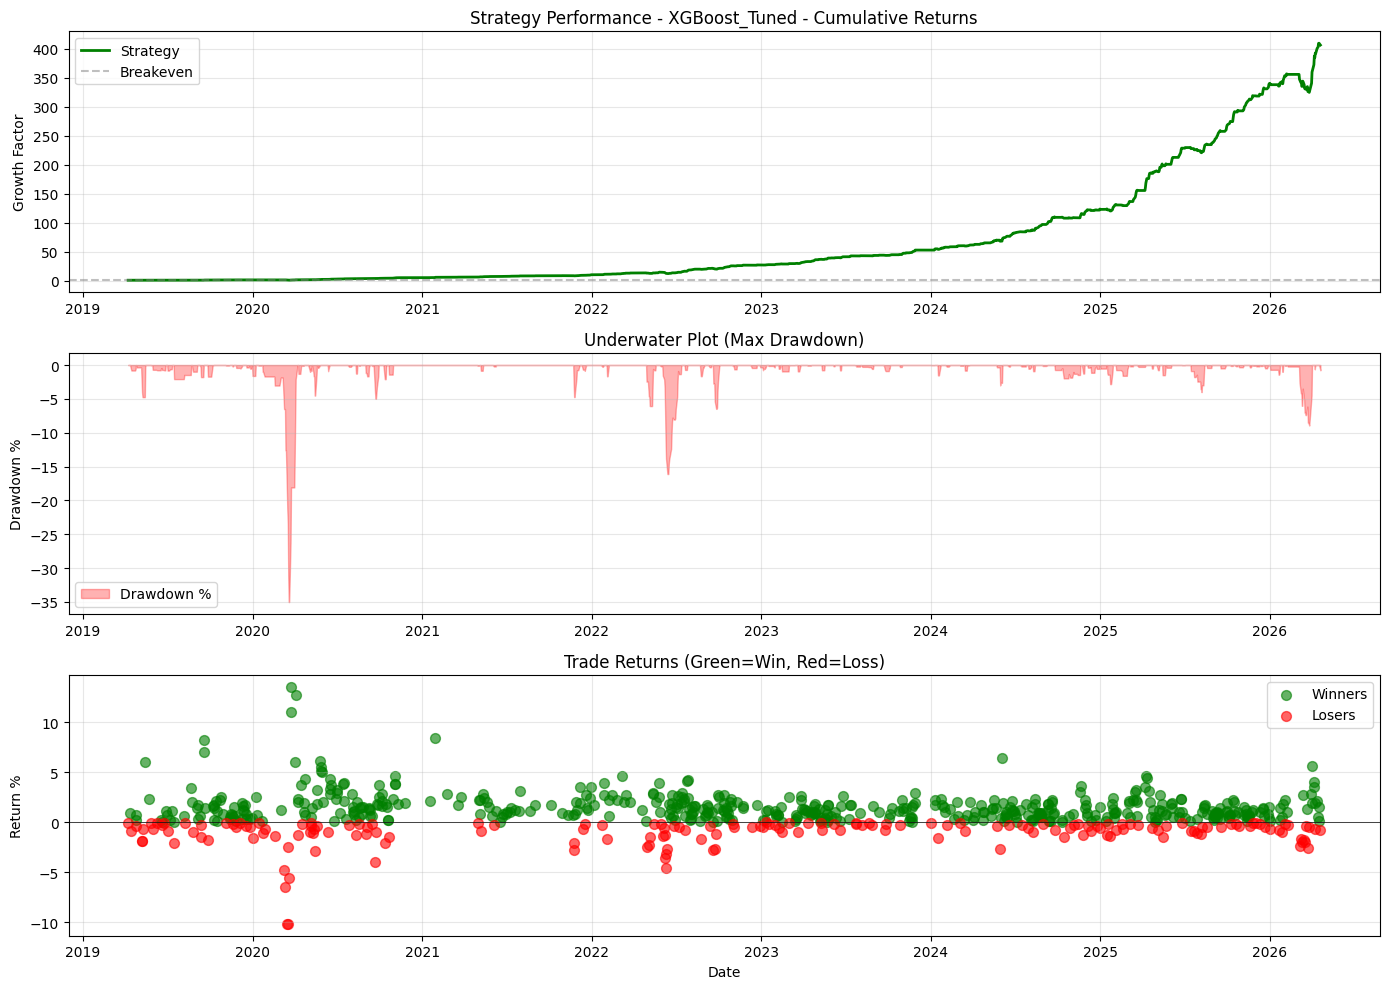

In [58]:
def plot_strategy_performance(backtest_df, title='Strategy Performance'):
    """
    Plot cumulative returns, drawdown, and win/loss scatter.
    """
    backtest_df = backtest_df.copy()
    backtest_df['Cumulative_Return'] = (1 + backtest_df['Strategy_Return'] / 100).cumprod()
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Cumulative returns
    axes[0].plot(backtest_df.index, backtest_df['Cumulative_Return'], label='Strategy', linewidth=2, color='green')
    axes[0].axhline(1, color='gray', linestyle='--', label='Breakeven', alpha=0.5)
    axes[0].set_title(f'{title} - Cumulative Returns')
    axes[0].set_ylabel('Growth Factor')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Drawdown
    running_max = backtest_df['Cumulative_Return'].cummax()
    drawdown = (backtest_df['Cumulative_Return'] - running_max) / running_max * 100
    axes[1].fill_between(backtest_df.index, drawdown, 0, color='red', alpha=0.3, label='Drawdown %')
    axes[1].set_title('Underwater Plot (Max Drawdown)')
    axes[1].set_ylabel('Drawdown %')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Win/Loss scatter
    trades = backtest_df[backtest_df['Prediction'] == 1]
    wins = trades[trades['Return_3d_Future'] > 0]
    losses = trades[trades['Return_3d_Future'] <= 0]
    axes[2].scatter(wins.index, wins['Return_3d_Future'], color='green', alpha=0.6, label='Winners', s=50)
    axes[2].scatter(losses.index, losses['Return_3d_Future'], color='red', alpha=0.6, label='Losers', s=50)
    axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[2].set_title('Trade Returns (Green=Win, Red=Loss)')
    axes[2].set_ylabel('Return %')
    axes[2].set_xlabel('Date')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot best model by Sharpe ratio
best_model = summary.index[0]
best_backtest = results[best_model]
plot_strategy_performance(best_backtest, f'Strategy Performance - {best_model}')

## 9. Dynamic Threshold Optimization
Find the threshold that maximizes Sharpe ratio, not just precision.

In [59]:
def optimize_threshold(data, model, features, start=None, step=250, threshold_range=np.arange(0.50, 0.76, 0.05)):
    """
    Find best threshold based on Sharpe ratio or cumulative return.
    """
    if start is None:
        data_len = len(data)
        start = min(1500, data_len - 500)
    
    results_by_threshold = {}
    
    for threshold in threshold_range:
        backtest_df = backtest_with_pnl(data, model, features, start, step, threshold)
        if len(backtest_df) == 0:
            continue
        metrics = compute_trading_metrics(backtest_df)
        results_by_threshold[round(threshold, 2)] = metrics
    
    # Convert to DataFrame for easy comparison
    results_df = pd.DataFrame(results_by_threshold).T
    results_df = results_df.sort_values('Sharpe_Ratio', ascending=False)
    
    return results_df, results_df.index[0]

# Optimize threshold for the best model
best_model_name = summary.index[0]
best_model = models[best_model_name]

print(f'Optimizing threshold for {best_model_name}...\n')
opt_results, best_threshold = optimize_threshold(df, best_model, ALL_FEATURES, threshold_range=np.arange(0.50, 0.76, 0.02))

print('=== Threshold Optimization Results ===')
print(opt_results[['Total_Trades','Win_Rate_%','Avg_Trade_Return_%','Cumulative_Return_%','Sharpe_Ratio','Max_Drawdown_%']])
print(f'\n✓ Best threshold: {best_threshold} (Sharpe={opt_results.loc[best_threshold,"Sharpe_Ratio"]:.3f})')

Optimizing threshold for XGBoost_Tuned...

=== Threshold Optimization Results ===
      Total_Trades  Win_Rate_%  Avg_Trade_Return_%  Cumulative_Return_%  \
0.56         739.0        74.3               0.875             55253.40   
0.58         713.0        74.6               0.893             50381.49   
0.64         642.0        76.0               0.943             37112.75   
0.60         688.0        74.7               0.894             40545.85   
0.62         660.0        75.3               0.914             36232.19   
0.66         615.0        76.1               0.952             30372.94   
0.54         763.0        73.8               0.837             50571.79   
0.52         787.0        73.3               0.819             53222.99   
0.68         595.0        76.1               0.964             27144.57   
0.70         576.0        76.4               0.964             22649.00   
0.50         818.0        72.7               0.791             54025.63   
0.72         549.0

Best model: XGBoost_Tuned
Best threshold: 0.56
Metrics at best threshold:
  Total_Trades.................. 739.0
  Win_Rate_%.................... 74.3
  Avg_Win_%..................... 1.526
  Avg_Loss_%.................... -1.007
  Avg_Trade_Return_%............ 0.875
  Cumulative_Return_%........... 55253.4
  Sharpe_Ratio.................. 4.714
  Max_Drawdown_%................ -34.99
  Signal_Rate_%................. 43.0


Best model: XGBoost_Tuned
Best threshold: 0.56
Metrics at best threshold:
  Total_Trades.................. 739.0
  Win_Rate_%.................... 74.3
  Avg_Win_%..................... 1.526
  Avg_Loss_%.................... -1.007
  Avg_Trade_Return_%............ 0.875
  Cumulative_Return_%........... 55253.4
  Sharpe_Ratio.................. 4.714
  Max_Drawdown_%................ -34.99
  Signal_Rate_%................. 43.0


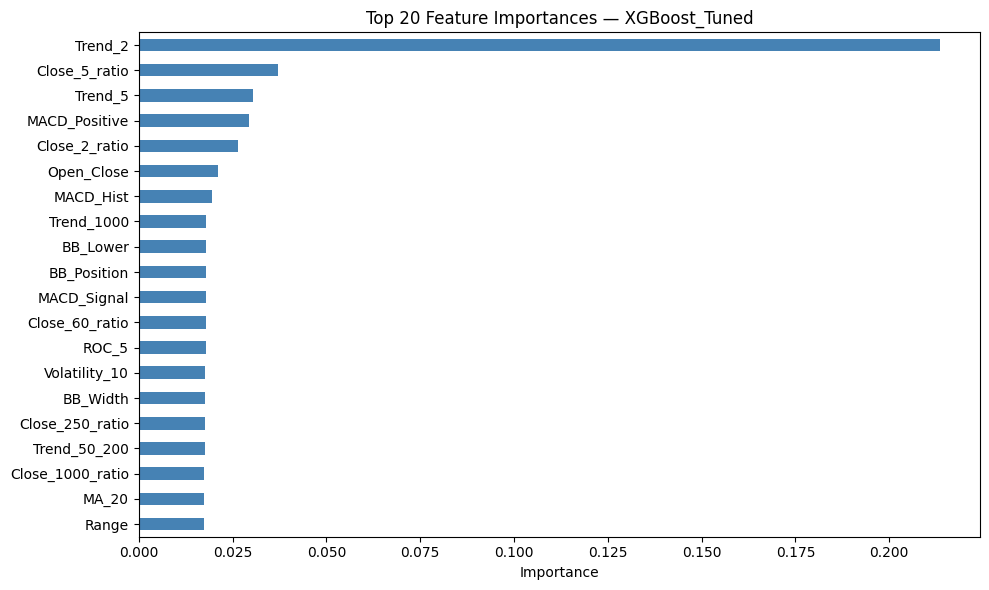

In [60]:
best_name = best_model_name
print(f'Best model: {best_name}')
print(f'Best threshold: {best_threshold}')
print(f'Metrics at best threshold:')
best_metrics = opt_results.loc[best_threshold]
for key, val in best_metrics.items():
    print(f'  {key:.<30} {val}')

# Refit on full training set to get feature importances
train_full = df.iloc[:-250]
best_mdl = models[best_name]
best_mdl.fit(train_full[ALL_FEATURES], train_full['Target_Direction'])

if hasattr(best_mdl, 'feature_importances_'):
    imp = pd.Series(best_mdl.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
    top20 = imp.head(20)
    plt.figure(figsize=(10, 6))
    top20.plot(kind='barh', color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances not available for this model type.')

In [61]:
# Get final backtest results with optimized threshold
data_len = len(df)
start = min(1500, data_len - 500)
final_backtest = backtest_with_pnl(df, best_mdl, ALL_FEATURES, start=start, step=250, threshold=best_threshold)
final_metrics = compute_trading_metrics(final_backtest)

print(f'\n=== Final Strategy Metrics: {best_name} (threshold={best_threshold}) ===\n')
for key, val in final_metrics.items():
    print(f'{key:.<35} {val}')

# Classification report (trades only)
trades = final_backtest[final_backtest['Prediction'] == 1]
if len(trades) > 0:
    correct_trades = (trades['Return_3d_Future'] > 0).sum()
    print(f'\n=== Trade Analysis ===')
    print(f'Total trades: {len(trades)}')
    print(f'Winning trades: {correct_trades}')
    print(f'Losing trades: {len(trades) - correct_trades}')
    print(f'Win rate: {correct_trades/len(trades)*100:.1f}%')
    print(f'Average winning trade: {trades[trades["Return_3d_Future"] > 0]["Return_3d_Future"].mean():.3f}%')
    print(f'Average losing trade: {trades[trades["Return_3d_Future"] <= 0]["Return_3d_Future"].mean():.3f}%')


=== Final Strategy Metrics: XGBoost_Tuned (threshold=0.56) ===

Total_Trades....................... 739
Win_Rate_%......................... 74.3
Avg_Win_%.......................... 1.526
Avg_Loss_%......................... -1.007
Avg_Trade_Return_%................. 0.875
Cumulative_Return_%................ 55253.4
Sharpe_Ratio....................... 4.714
Max_Drawdown_%..................... -34.99
Signal_Rate_%...................... 43.0

=== Trade Analysis ===
Total trades: 739
Winning trades: 549
Losing trades: 190
Win rate: 74.3%
Average winning trade: 1.526%
Average losing trade: -1.007%


## 8. Recent Predictions vs Actual

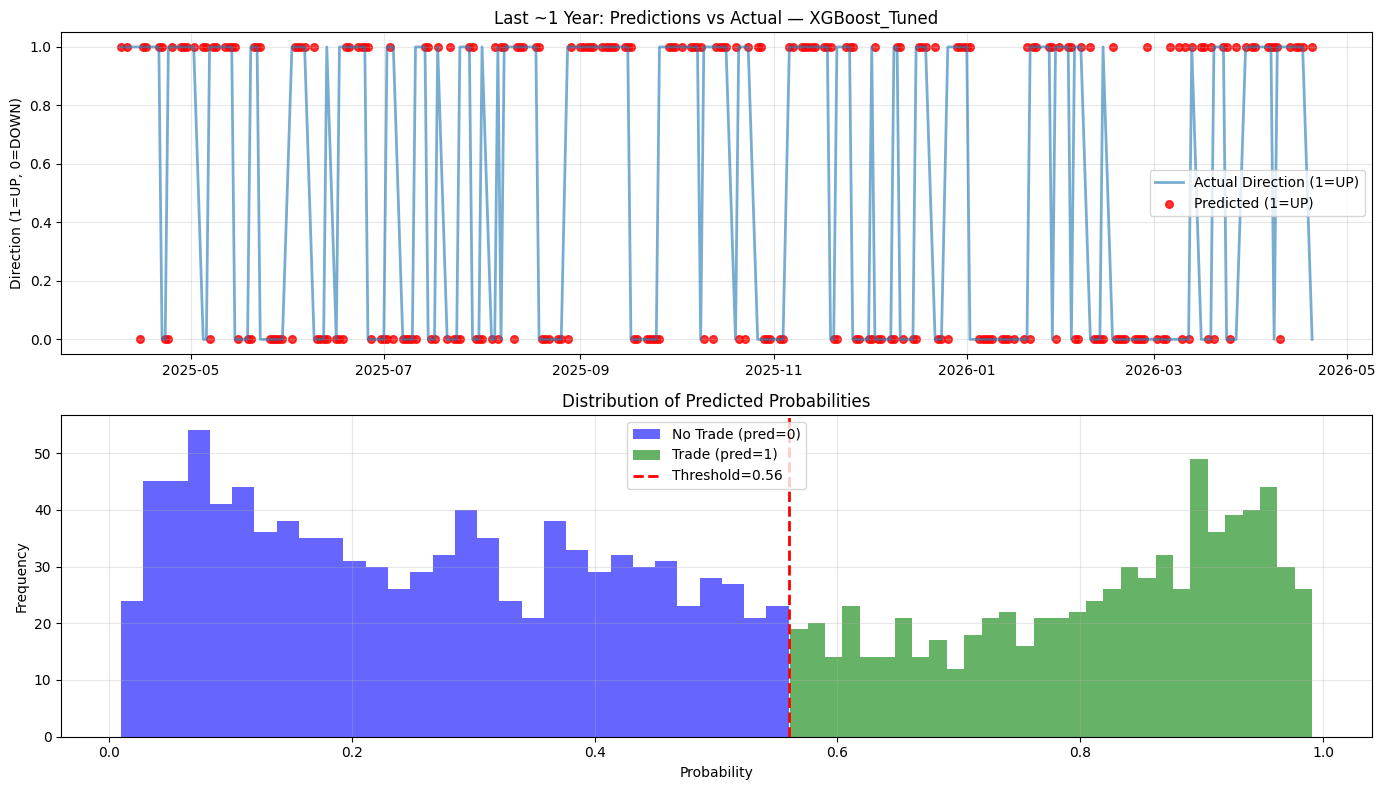

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Recent predictions vs actual
recent = final_backtest.tail(252).copy()
recent['Actual_Direction'] = (recent['Return_3d_Future'] > 0).astype(int)

axes[0].plot(recent.index, recent['Actual_Direction'], label='Actual Direction (1=UP)', alpha=0.6, linewidth=2)
axes[0].scatter(recent.index, recent['Prediction'], label='Predicted (1=UP)', alpha=0.8, s=30, color='red')
axes[0].set_title(f'Last ~1 Year: Predictions vs Actual — {best_name}')
axes[0].set_ylabel('Direction (1=UP, 0=DOWN)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Probability distribution
axes[1].hist(final_backtest[final_backtest['Prediction'] == 0]['Probability'], bins=30, alpha=0.6, label='No Trade (pred=0)', color='blue')
axes[1].hist(final_backtest[final_backtest['Prediction'] == 1]['Probability'], bins=30, alpha=0.6, label='Trade (pred=1)', color='green')
axes[1].axvline(best_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={best_threshold}')
axes[1].set_title('Distribution of Predicted Probabilities')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()